In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression

In [2]:
df = pd.read_csv('./Melbourne_housing_FULL.csv')
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [3]:
df.shape

(34857, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 non-null  float64
 18  Longti

In [5]:
null_df = df.isnull().sum()\
                .reset_index()\
                .rename({'index':'Column', 0:'Missing Count'}, axis=1)\
                .sort_values('Missing Count',ascending=False)

null_df['Missing Pct (%)'] = round((null_df['Missing Count'] / len(df)) * 100)
null_df

,Column,Missing Count,Missing Pct (%)
14,BuildingArea,21115,61.0
15,YearBuilt,19306,55.0
13,Landsize,11810,34.0
12,Car,8728,25.0
11,Bathroom,8226,24.0
10,Bedroom2,8217,24.0
18,Longtitude,7976,23.0
17,Lattitude,7976,23.0
4,Price,7610,22.0
19,Regionname,3,0.0


In [6]:
df.dropna(subset= 'Price', inplace = True)

In [7]:
categorical_cols = df.select_dtypes('object').columns
high_cardinal_cols = []
for i in categorical_cols:
    if df[str(i)].nunique() > 15:
        high_cardinal_cols.append(i)
        print(f"{i}: {df[str(i)].nunique()} - HIGH CARDINALITY")
        continue
    print(f"{i}: {df[str(i)].nunique()}")


Suburb: 345 - HIGH CARDINALITY
Address: 26751 - HIGH CARDINALITY
Type: 3
Method: 5
SellerG: 349 - HIGH CARDINALITY
Date: 78 - HIGH CARDINALITY
CouncilArea: 33 - HIGH CARDINALITY
Regionname: 8


In [8]:
df_baseline = df[["Rooms", "Landsize", "BuildingArea", "Price"]]
df_baseline.dropna(inplace = True)

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_3524\3549373438.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_baseline.dropna(inplace = True)


In [9]:
X = df_baseline.drop('Price', axis = 1)
y = df_baseline['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state= 42)

In [10]:
model = LinearRegression()
kfold = KFold(n_splits= 5)

In [ ]:
score = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
print(f"Mean R2: {np.mean(score)}")
print(f"Std Dev R2: {np.std(score)}")

Mean R2: 0.22297633860274554
Std Dev R2: 0.050695390943122386


# Task 2 — Menangani Missing Values


In [12]:
null_20_cols = null_df[null_df['Missing Pct (%)'] <= 20]['Column'].to_list()

In [13]:
df_clean = df.copy()
df_clean[null_20_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 27247 entries, 1 to 34856
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Regionname     27244 non-null  object 
 1   CouncilArea    27244 non-null  object 
 2   Propertycount  27244 non-null  float64
 3   Postcode       27246 non-null  float64
 4   Distance       27246 non-null  float64
 5   Address        27247 non-null  object 
 6   Date           27247 non-null  object 
 7   SellerG        27247 non-null  object 
 8   Method         27247 non-null  object 
 9   Type           27247 non-null  object 
 10  Rooms          27247 non-null  int64  
 11  Suburb         27247 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 2.7+ MB


In [14]:
# df_clean.drop(high_cardinal_cols, axis = 1, inplace = True)

In [15]:
# high_cardinal_cols

In [16]:
df_clean[null_20_cols].describe()

,Propertycount,Postcode,Distance,Rooms
count,27244.000000,27246.000000,27246.000000,27247.000000
mean,7566.781089,3113.796080,11.280276,2.992293
std,4492.382418,111.139676,6.787469,0.954795
min,83.000000,3000.000000,0.000000,1.000000
25%,4294.000000,3046.000000,6.400000,2.000000
50%,6567.000000,3088.000000,10.500000,3.000000
75%,10412.000000,3153.000000,14.000000,4.000000
max,21650.000000,3978.000000,48.100000,16.000000


In [17]:
df_clean[null_20_cols].describe(include='O')

,Regionname,CouncilArea,Address,Date,SellerG,Method,Type,Suburb
count,27244,27244,27247,27247,27247,27247,27247,27247
unique,8,33,26751,78,349,5,3,345
top,Southern Metropolitan,Boroondara City Council,5 Charles St,28/10/2017,Nelson,S,h,Reservoir
freq,8524,2520,4,879,2735,17515,18472,727


In [18]:
df_clean[null_20_cols].select_dtypes('number').isna().sum()

Propertycount    3
Postcode         1
Distance         1
Rooms            0
dtype: int64

In [19]:
df_clean[null_20_cols].select_dtypes('object').isna().sum()

Regionname     3
CouncilArea    3
Address        0
Date           0
SellerG        0
Method         0
Type           0
Suburb         0
dtype: int64

In [20]:
df_clean.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [21]:
high_cardinal_cols

['Suburb', 'Address', 'SellerG', 'Date', 'CouncilArea']

In [22]:
df_clean.drop(['Date','CouncilArea'],axis = 1, inplace = True)

In [23]:
df_clean['Propertycount'] = df_clean['Propertycount'].fillna(df_clean['Propertycount'].mean())
df_clean['Postcode'] = df_clean['Postcode'].fillna(df_clean['Postcode'].median())
df_clean['Distance'] = df_clean['Distance'].fillna(df_clean['Distance'].mean())
df_clean['Regionname'] = df_clean['Regionname'].fillna(df_clean['Regionname'].mode())
# df_clean['CouncilArea'] = df_clean['CouncilArea'].fillna(df_clean['CouncilArea'].mode())

Berdasarkan summary statistik, semua kolom numerik memiliki angka mean dan median yang berdekatan. artinya, data mendekati distribusi normal. sehingga imputasi untuk kolom numerik yang memiliki null dapat diisi dengan mean. Terkecuali untuk kolom postcode yang diisi median, dikarenakan agar angka valid

In [24]:
df_clean.dropna(inplace = True)

# Task 3 — Menangani High Cardinality

In [25]:
df_clean['Suburb_freq'] = df_clean['Suburb'].map(df_clean['Suburb'].value_counts())
df_clean.drop('Suburb', axis=1, inplace=True)

In [26]:
df_clean.groupby('SellerG')['Price'].mean().reset_index()

,SellerG,Price
0,@Realty,8.397500e+05
1,Abercromby's,2.398250e+06
2,Ace,6.000000e+05
3,Alexkarbon,9.426144e+05
4,Allens,1.461400e+06
...,...,...
245,hockingstuart/hockingstuart,8.686667e+05
246,iOne,6.200000e+05
247,iProperty,8.200000e+05
248,iSell,7.269286e+05


In [27]:
df_clean.isna().sum().sum()

np.int64(0)

In [28]:
from sklearn.preprocessing import TargetEncoder
enc=TargetEncoder()
df_clean['SellerG_encoded'] = enc.fit_transform(df_clean['SellerG'].to_numpy().reshape(-1,1),
                  df_clean.groupby('SellerG')['Price'].transform('mean').to_numpy().reshape(-1,1)).reshape(1,-1)[0]

df_clean.drop('SellerG',axis=1, inplace=True)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [29]:
df_clean.head()

,Address,Rooms,Type,Price,Method,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Regionname,Propertycount,Suburb_freq,SellerG_encoded
2,25 Bloomburg St,2,h,1035000.0,S,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,-37.8079,144.9934,Northern Metropolitan,4019.0,39,1.092821e+06
4,5 Charles St,3,h,1465000.0,SP,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,-37.8093,144.9944,Northern Metropolitan,4019.0,39,1.092821e+06
6,55a Park St,4,h,1600000.0,VB,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,-37.8072,144.9941,Northern Metropolitan,4019.0,39,1.047920e+06
11,124 Yarra St,3,h,1876000.0,S,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,-37.8024,144.9993,Northern Metropolitan,4019.0,39,1.047920e+06
14,98 Charles St,2,h,1636000.0,S,2.5,3067.0,2.0,1.0,2.0,256.0,107.0,1890.0,-37.8060,144.9954,Northern Metropolitan,4019.0,39,1.047920e+06


In [30]:
df_clean.drop('Address', axis = 1, inplace=True)

terlalu spesifik, namun tidak ada informasi tambahan terkait state. jika di drop masih ada informasi yang digunakan melalui kolom regionname dan postcode

In [31]:
cat_encoded = pd.get_dummies(df_clean[['Type', 'Method', 'Regionname']], drop_first= True)
df_clean = pd.concat([df_clean, cat_encoded], axis= 1)
df_clean.drop(['Type', 'Method', 'Regionname'], axis=1, inplace = True)

# Task 4 — Deteksi dan Penanganan Outlier

Text(0.5, 0, 'BuildingArea')

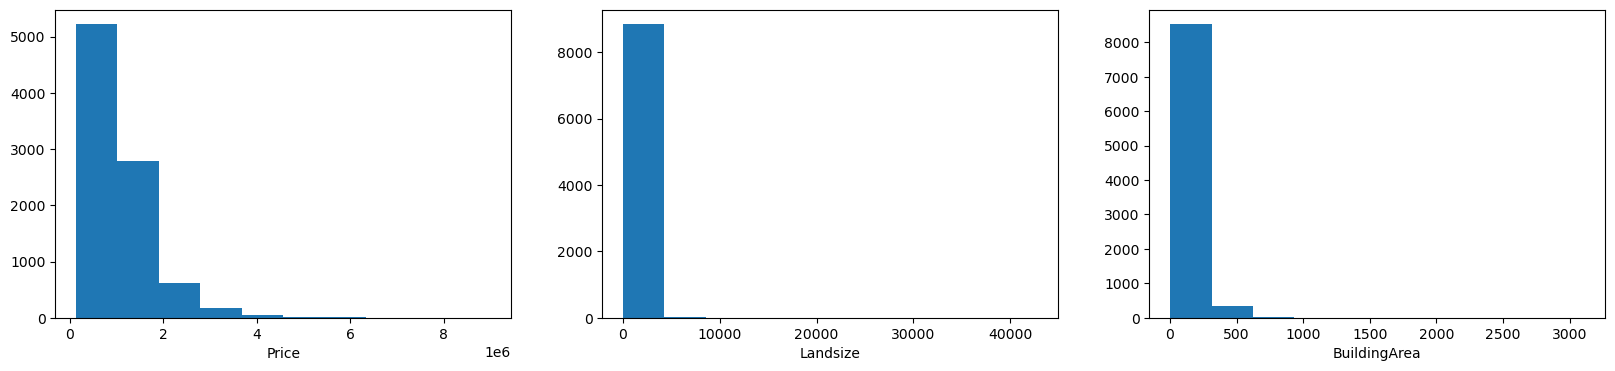

In [32]:
fig, ax = plt.subplots(1,3, figsize=(20,4))
ax[0].hist(df_clean['Price'])
ax[0].set_xlabel('Price')

ax[1].hist(df_clean['Landsize'])
ax[1].set_xlabel('Landsize')

ax[2].hist(df_clean['BuildingArea'])
ax[2].set_xlabel('BuildingArea')

In [33]:
q1_price = df_clean['Price'].quantile(0.25)
q3_price = df_clean['Price'].quantile(0.75)
iqr_price = q3_price - q1_price

lower_bound = q1_price - 1.5 * iqr_price
upper_bound = q3_price + 1.5 * iqr_price

print(f"Outliers: {len(df_clean[df['Price'] < lower_bound]) + len(df_clean[df['Price'] > upper_bound])}")

Outliers: 420


D:\Users\bsi80273\AppData\Local\Temp\ipykernel_3524\1359045986.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f"Outliers: {len(df_clean[df['Price'] < lower_bound]) + len(df_clean[df['Price'] > upper_bound])}")
D:\Users\bsi80273\AppData\Local\Temp\ipykernel_3524\1359045986.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f"Outliers: {len(df_clean[df['Price'] < lower_bound]) + len(df_clean[df['Price'] > upper_bound])}")


In [34]:
df_clean['Price'] = df_clean['Price'].clip(lower=lower_bound, upper=upper_bound)

In [35]:
z_scores = stats.zscore(df_clean['Landsize'].dropna())
z_scores_full = pd.Series(stats.zscore(df_clean['Landsize'].fillna(df_clean['Landsize'].mean())), index=df_clean.index)

outlier_mask = z_scores_full.abs() > 3
print(f"Jumlah outlier terdeteksi: {outlier_mask.sum()}")

df_clean = df_clean[~outlier_mask]
print(f"Jumlah baris setelah trimming: {len(df_clean)}")


Jumlah outlier terdeteksi: 63
Jumlah baris setelah trimming: 8824


Text(0.5, 0, 'Landsize')

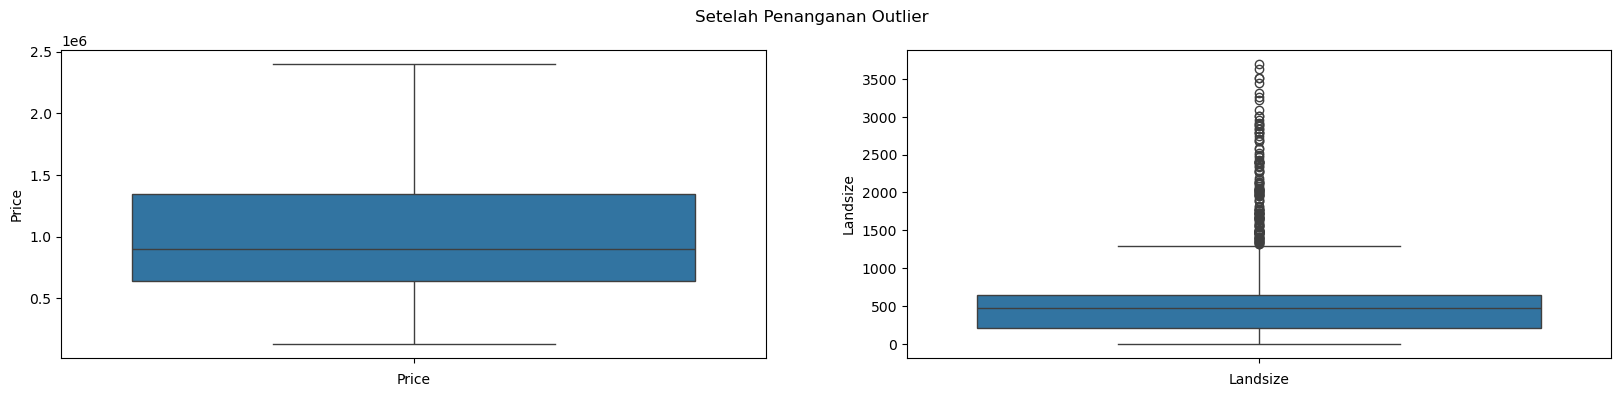

In [36]:
fig, ax = plt.subplots(1,2, figsize=(20,4))
fig.suptitle("Setelah Penanganan Outlier")

sns.boxplot(df_clean['Price'], ax=ax[0])
ax[0].set_xlabel('Price')

sns.boxplot(df_clean['Landsize'], ax=ax[1])
ax[1].set_xlabel('Landsize')



# Task 5 — Evaluasi Akhir dan Perbandingan

In [38]:
X_final = df_clean.drop('Price', axis = 1)
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

In [39]:
kfold = KFold(n_splits=5)
model = LinearRegression ()

In [40]:
df_clean

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,...,Method_SA,Method_SP,Method_VB,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
2,2,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,...,False,False,False,False,True,False,False,False,False,False
4,3,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,...,False,True,False,False,True,False,False,False,False,False
6,4,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,...,False,False,True,False,True,False,False,False,False,False
11,3,1876000.0,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,...,False,False,False,False,True,False,False,False,False,False
14,2,1636000.0,2.5,3067.0,2.0,1.0,2.0,256.0,107.0,1890.0,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34847,3,500000.0,25.5,3750.0,3.0,2.0,2.0,383.0,118.0,2016.0,...,False,False,False,False,True,False,False,False,False,False
34849,3,570000.0,25.5,3750.0,3.0,2.0,2.0,404.0,158.0,2012.0,...,False,True,False,False,True,False,False,False,False,False
34853,2,888000.0,6.3,3013.0,2.0,2.0,1.0,98.0,104.0,2018.0,...,False,True,False,False,False,False,False,False,True,False
34854,2,705000.0,6.3,3013.0,2.0,1.0,2.0,220.0,120.0,2000.0,...,False,False,False,False,False,False,False,False,True,False


In [41]:
score = cross_val_score(model,X_train, y_train, cv=kfold, scoring='r2')
print("Standard Deviasion R2:", np.std(score))
print("Mean R2:", np.mean(score))

Standard Deviasion R2: 0.007730302655897049
Mean R2: 0.7468310801922179


Langkah yang paling berdamapak dalam peningkatan r2 adalah adanya effort lebih untuk mempertahankan kolom kategorikal. Pada baseline, eksperimen dilakukan hanya dengan kolom numerik, namun di ekperimen selanjutnya ada usaha agar sebaik mngkin untuk menjaga informasi di kolom kategorikal. Usaha yang dilakukan antara lain menanganin missing value, encoding yang optimal supaya tidak high cardinality, dan handling outliers. Sehingga eksperimen setelah baseline memiliki lebih banyak informasi dibandingkan baseline. 